# When a zero is a lie

*Question, Intuition, Math, Code, Assumptions, How it breaks*

One of my twelve requirements is **discipline**: cards and fouls, negated so a
clean player scores above a dirty one. Under the percentile gate every
season-level requirement eliminates almost exactly the same number of players,
2,203 of 5,508, because each floor is set at the same percentile of its own
column. Discipline is not special in that respect. What makes it worth a
chapter is not how many players it eliminates but how it eliminates them.

It is also built on a column the source did not always record. And
`groupby().sum()` will turn a column of nothing into a column of zeros without a
word of complaint. A zero in a fouls column says something very specific, and
false: *he fouled nobody.*

Here is the part I did not expect. This turns out to be **completely harmless in
most of the data and genuinely damaging in a little of it**, and which is which
has nothing to do with how much is missing.

## 1. Question

A column the gate depends on is missing for part of the data. What do I put
there, and how much does the answer actually matter?

## 2. Intuition

There are three answers, and the usual way people choose between them is to ask
how *much* is missing. I think that is the wrong question.

**Put a zero.** This is what you get by not deciding. It claims the player fouled
nobody.

**Put the group's average.** Now the player scores neither well nor badly, which
sounds fair. But an average carries no variance, so injecting it narrows the
spread of whatever group it lands in.

**Drop the term.** Discipline falls back to cards alone. It measures something
coarser, but it measures it the same way for everyone.

The question that actually decides the damage is not how much is missing but
**where**. Specifically, whether the hole lines up with the groups you normalise
inside. Every score in this project is z-scored within its own
`(league, season)`. A hole that fills one of those groups completely behaves
nothing like a hole scattered across one.

## 3. Math

The textbook taxonomy first. **MCAR** means absence is independent of everything,
so dropping and imputing are both safe. **MAR** means absence depends on columns
you observed, so conditional imputation is defensible. **MNAR** means absence
depends on the value itself or on something you never measured, and nothing is
safe.

Fouls here are not MCAR. Absence is predicted almost perfectly by
`(league, season)`, which technically makes them MAR given a variable I hold.

But the taxonomy is not what decides the damage, and this is the bit I want to
show you. Take a requirement $x$ z-scored within group $g$:

$$z_{ig} = \frac{x_{ig} - \bar{x}_g}{\sigma_g}$$

If every member of $g$ is missing, and every one gets filled with the same
constant, that constant goes into $\bar{x}_g$ and cancels straight back out. The
fill **cannot** change any $z$ in that group. It adds nothing to the spread and
nothing to the mean difference.

If instead a handful inside $g$ get filled while the rest carry real values,
those few have been placed at a specific point on a scale everybody else earned.
Now the fill is a claim, and it is being compared against measurements.

**Same fill, same column, same fraction missing, opposite consequences.**

## 4. Code

### Where the hole actually is

In [1]:
import numpy as np
import pandas as pd

from gambeta import level, needs

seasons = pd.read_parquet("../data/sample/player_season_scored.parquet")
seasons["year"] = 2000 + seasons["season"].str[:2].astype(int)

covered = seasons.groupby(["league", "year"])["fouls"].apply(lambda s: s.notna().mean())
covered.to_frame("share").pivot_table(index="league", columns="year", values="share").loc[
    :, :2007
].round(2)

year,2000,2001,2002,2003,2004,2005,2006,2007
league,,,,,,,,
ENG-Premier League,1.0,0.99,1.00,1.00,0.99,1.00,0.99,1.0
ESP-La Liga,1.0,1.00,1.00,0.99,0.99,1.00,1.00,1.0
FRA-Ligue 1,0.0,0.00,0.00,0.00,0.00,0.00,0.98,1.0
GER-Bundesliga,0.0,0.00,0.00,0.00,0.00,0.00,1.00,1.0
ITA-Serie A,1.0,1.00,0.99,0.99,0.99,0.99,0.99,1.0


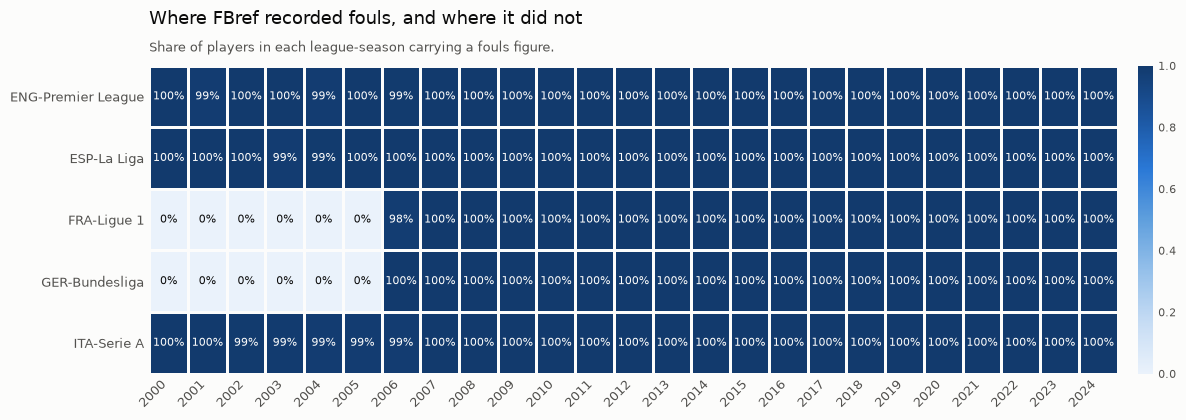

In [2]:
from gambeta import tifo

grid = covered.to_frame("share").pivot_table(index="league", columns="year", values="share")

fig = tifo.matrix(
    grid,
    title="Where FBref recorded fouls, and where it did not",
    subtitle="Share of players in each league-season carrying a fouls figure.",
    fmt="{:.0%}",
    label_if=None,
    scale=(0.0, 1.0),
)

Two solid bands of nothing, and they are not an era. England, Spain and Italy
are complete from 2000. France and Germany are empty until 2006 and complete
after it. There is no league-season anywhere near the 60% that an average across
all five leagues would report.

That is not an era ramp, and it is not record-keeping gradually improving.

**England, Spain and Italy have fouls from 2000 onwards.** France and Germany
have none at all until 2006, and then have them completely. Twelve league-seasons
of exactly nothing, sitting next to sixty-odd that are exactly complete.

I want to flag what I nearly did here. An average taken across all five leagues
reports "about 60% coverage in the early years", and that describes a dataset
which does not exist. There is no league-season anywhere at 60%.

In [3]:
share = seasons.groupby(["league", "year"])["fouls"].transform(lambda s: s.notna().mean())
regime = pd.cut(
    share,
    [-0.01, 0.001, 0.999, 1.01],
    labels=["wholly missing", "partly covered", "fully covered"],
)

summary = (
    seasons.assign(regime=regime)
    .groupby("regime", observed=True)
    .agg(
        rows=("fouls", "size"),
        missing=("fouls", lambda s: int(s.isna().sum())),
    )
)
summary["share missing"] = (summary["missing"] / summary["rows"]).map("{:.1%}".format)
summary

,rows,missing,share missing
regime,,,
wholly missing,3508,3508,100.0%
partly covered,6433,48,0.7%
fully covered,29936,0,0.0%


Three regimes, and only the middle one is a problem.

### A hole that fills the whole group is free

Take one of the twelve wholly-missing league-seasons and score discipline two
ways: with zeros, and with the term dropped entirely.

In [4]:
group = seasons[(seasons["league"] == "GER-Bundesliga") & (seasons["year"] == 2002)].copy()
per90 = group["minutes"] / 90

group["with_zeros"] = -(group["red"] + group["second_yellow"] + group["fouls"].fillna(0) / per90)
group["term_dropped"] = -(group["red"] + group["second_yellow"])

scored = level.zscore(group, ["with_zeros", "term_dropped"])
same = np.allclose(scored["with_zeros_z"], scored["term_dropped_z"])

print(f"{len(group)} players, {group['fouls'].isna().sum()} missing a fouls figure")
print(f"identical z-scores either way: {same}")
print("\nThe fill was constant across the whole group, so it cancelled.")

287 players, 287 missing a fouls figure
identical z-scores either way: True

The fill was constant across the whole group, so it cancelled.


Nothing to argue about there. The zero was a lie, and the lie made no
difference, because every player in the group told exactly the same one.

### A hole scattered inside the group is not free

Now take a league-season that is *almost* complete. This is the middle regime,
where a handful of players lack a figure and everyone else has one.

In [5]:
partial = seasons[(share > 0.001) & (share < 0.999)]
worst = partial.groupby(["league", "year"])["fouls"].apply(lambda s: s.isna().sum()).idxmax()
g = seasons[(seasons["league"] == worst[0]) & (seasons["year"] == worst[1])].copy()
rate = g["fouls"] / (g["minutes"] / 90)

measured = rate.dropna()
print(f"{worst[0]} {worst[1]}: {len(g)} players, {int(rate.isna().sum())} without a fouls figure\n")
print("a zero-filled player is recorded at  : 0.00 fouls per 90")
print(f"measured players strictly worse      : {100 * (measured > 0).mean():.0f}%")
print(f"measured players genuinely also at 0 : {int((measured == 0).sum())}")
print("\nThe fill invents no record better than anyone's. It places every unrecorded")
print("player at the cleanest end of a scale the others had to earn.")

FRA-Ligue 1 2006: 312 players, 5 without a fouls figure

a zero-filled player is recorded at  : 0.00 fouls per 90
measured players strictly worse      : 92%
measured players genuinely also at 0 : 25

The fill invents no record better than anyone's. It places every unrecorded
player at the cleanest end of a scale the others had to earn.


That is the real cost, and I want to be precise about its size rather than
dramatic. **610 rows out of 65,069**, and only **48 of those clear the
900-minute floor** and reach the ranking at all. The median one played 32
minutes. It is a real distortion and it is a rounding error.

I am recording that because the temptation was to fix it. A group mean instead
of a zero would have been ten lines and would have felt like diligence. Measured
first, it moves 48 marginal player-seasons inside a minutes-weighted average, so
the honest answer is to leave it alone and say so.

### The column where it does bite

Fouls are not the only thing `misc` carries. Second yellows come from the same
table, and they have a different shape entirely.

In [6]:
import inspect

coverage = seasons.groupby("year")["second_yellow"].apply(lambda s: s.notna().mean())
print("second yellow, share of rows carrying a figure:")
print(coverage.round(2).to_string())

second yellow, share of rows carrying a figure:
year
2000    0.05
2001    0.08
2002    0.06
2003    0.07
2004    0.08
2005    0.11
2006    0.10
2007    0.10
2008    0.11
2009    0.10
2010    0.10
2011    0.10
2012    0.13
2013    0.11
2014    0.11
2015    0.32
2016    1.00
2017    1.00
2018    1.00
2019    1.00
2020    1.00
2021    1.00
2022    1.00
2023    1.00
2024    1.00


In [7]:
naive_sy = seasons["second_yellow"].fillna(0.0).to_numpy(dtype=float)
guarded_sy = needs._misc_term(seasons, "second_yellow")

naive_f = needs._rate(seasons["fouls"].fillna(0.0), seasons["minutes"])
guarded_f = needs._misc_term(seasons, "fouls", seasons["minutes"])

print(f"second yellow: rows the guard changes {int((~np.isclose(naive_sy, guarded_sy)).sum()):,}")
print(f"fouls        : rows the guard changes {int((~np.isclose(naive_f, guarded_f)).sum()):,}")
print()
print(inspect.getsource(needs._misc_term))
print(f"MISC_COVERAGE = {needs.MISC_COVERAGE}")

second yellow: rows the guard changes 1,555
fouls        : rows the guard changes 0

def _misc_term(df: pd.DataFrame, column: str, minutes: pd.Series | None = None) -> np.ndarray:
    """A `misc` column, zeroed out in league-seasons the source barely recorded.

    Passing ``minutes`` turns the column into a per-90 rate; leaving it out keeps
    the raw count, which is what a card tally wants.
    """
    if column not in df.columns:
        return np.zeros(len(df), dtype=float)
    recorded = df[column].notna()
    covered = recorded.groupby([df["league"], df["season"]]).transform("mean")
    usable = (recorded & (covered >= MISC_COVERAGE)).to_numpy()
    values = df[column].fillna(0.0)
    present = _rate(values, minutes) if minutes is not None else values.to_numpy(dtype=float)
    return np.where(usable, present, 0.0)

MISC_COVERAGE = 0.8


Around a tenth of players carry a figure until 2015, then it jumps to all of
them. For most of this window a blank in that column cannot be told apart from a
zero.

Now look at the two numbers above. The guard changes **no fouls rows at all**,
because every league-season below the floor is at exactly 0% coverage, which is
the regime where a constant fill already cancels inside a z-score. On fouls it
carefully protects the case that was already safe.

On second yellows it changes every row printed above, and those are the ones
that were genuinely being wronged: players who did pick up a second yellow in a
season where nine in ten of their peers' second yellows were never written down,
so they carried a penalty their rivals were structurally exempt from.

I built the guard for fouls, having reasoned carefully about fouls, and it turned
out to matter for the column I had not looked at.

## 5. Assumptions

1. **Absence is a property of the source, not the player.** A missing fouls
   figure means FBref published none. It is never read as "he committed none",
   which is precisely what the zero claims.
2. **Cards alone are still a discipline signal.** Coarser, yes, but reds and
   second yellows are recorded throughout, so the wholly-missing groups still
   rank players on something real.
3. **The grain of normalisation is `(league, season)`.** Every argument in this
   chapter depends on that. Change the grain and which holes are harmless changes
   with it.

## 6. How it breaks

**I reasoned about the wrong column, and only measuring caught it.**

I wrote the guard from a description that was entirely true: fouls are patchy in
the early era, so drop the term where coverage is thin. Every word of that is
correct. It is also aimed at a regime where the problem cancels on its own, and
on fouls the guard changes nothing whatsoever.

What I had not done was look at the other column from the same table. Second
yellows sit at 10 to 16% coverage for fifteen seasons, which is the damaging
shape, and I had been filling them with zero the entire time without ever
checking. The guard earns its place on a column I was not thinking about.

No test would have caught either half of that. There is no bug here. The code
computes exactly what it says and its output is sensible. The assumption
underneath it, that thin coverage and damaging coverage are the same thing, was
simply never checked against the data.

**The fix I did not build.** For the middle regime the tempting move is to score
a missing player at the group mean rather than zero: neutral instead of
best-in-class, ten lines, and it feels like diligence. Measured first, it moves
48 player-seasons that clear the minutes floor, each a marginal player, inside an
average already weighted by minutes. So it is not built, and this paragraph is
here instead. Writing code to fix a rounding error is how a codebase gets heavy.

**What no fix repairs.** Discipline in Bundesliga 2002 ranks players on cards. In
La Liga 2002 it ranks them on cards and fouls. Both get z-scored onto the same
scale, the gate treats them as the same requirement, and they are not measuring
the same thing. Three Ballon d'Or winners, Nedved, Figo and Rodri, fail my gate
on discipline alone.

That is a limitation of the source. It belongs out in the open rather than
smoothed over with a plausible-looking fill.